In [15]:
# Run this in first cell
from google.colab import files
uploaded = files.upload()
# Then click "Choose Files" and select your CSV file

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [16]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Show shape of dataset
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Show info
print("\nDataset Information:")
df.info()

# Show statistical summary
print("\nStatistical Summary:")
df.describe()

# Show count of missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Show value counts of target column
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn Percentages:")
print(df['Churn'].value_counts(normalize=True) * 100)

Dataset shape: (7043, 21)
Rows: 7043, Columns: 21

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract         

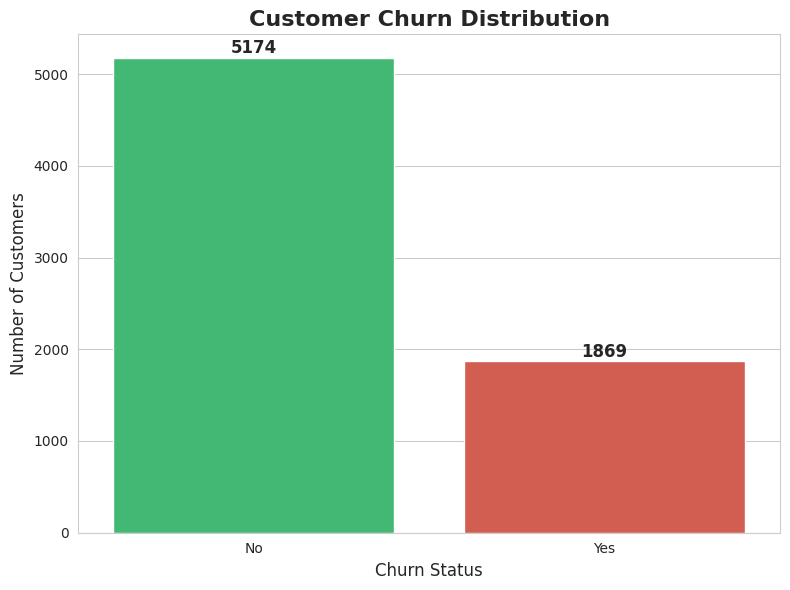

In [19]:
# Count plot for Churn distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add value labels on bars
for i in range(len(df['Churn'].value_counts())):
    plt.text(i, df['Churn'].value_counts().values[i] + 50,
             str(df['Churn'].value_counts().values[i]),
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

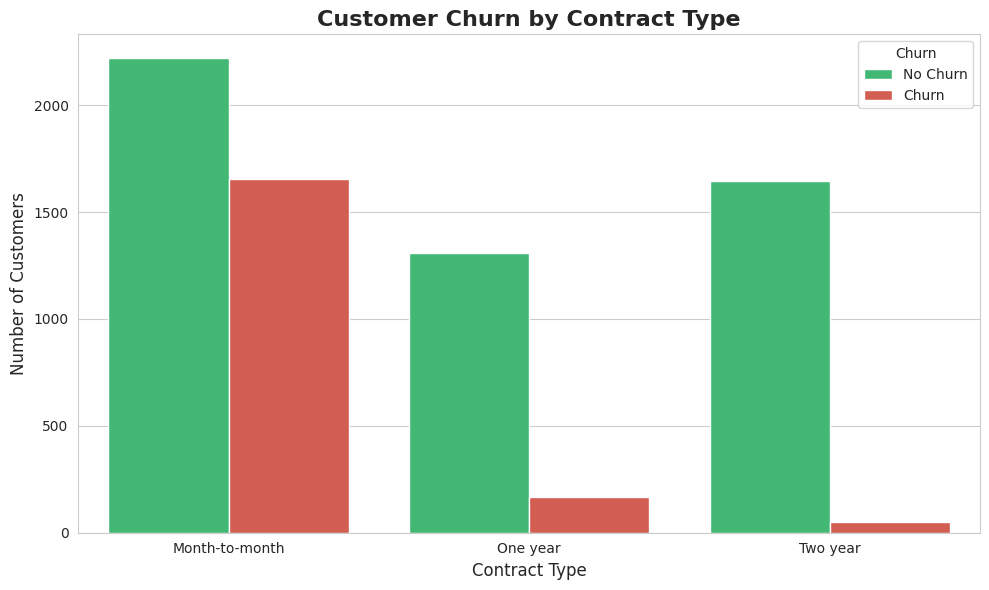

In [20]:
# Count plot for Churn vs Contract Type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

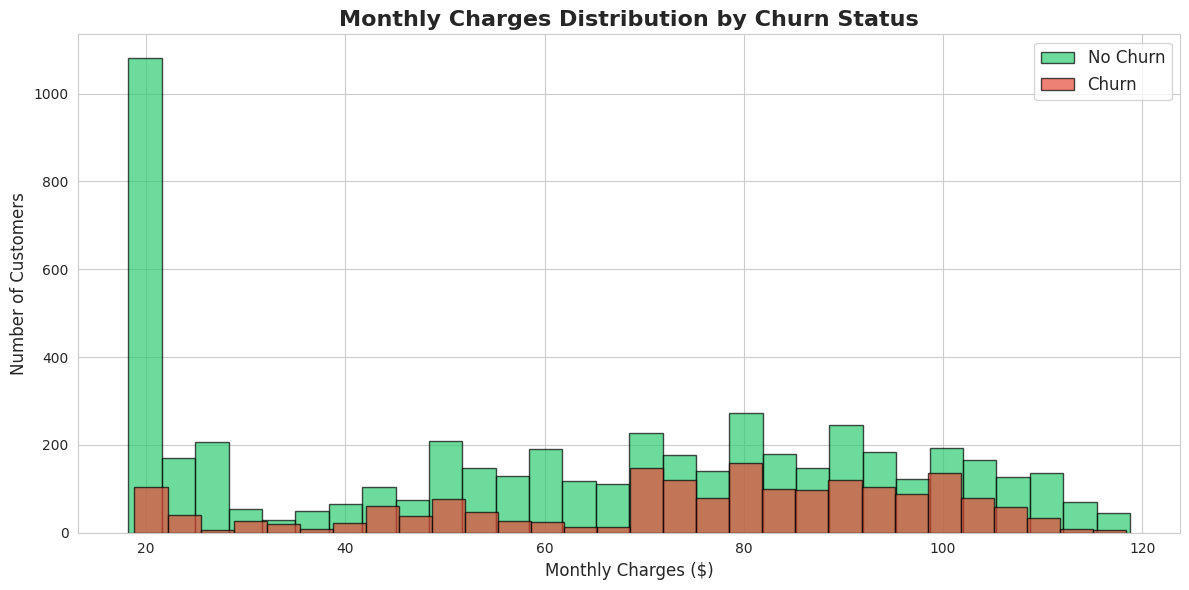

In [21]:
# Histogram of MonthlyCharges by Churn status
plt.figure(figsize=(12, 6))

# For non-churned customers
churn_no = df[df['Churn'] == 'No']['MonthlyCharges']
plt.hist(churn_no, bins=30, alpha=0.7, label='No Churn', color='#2ecc71', edgecolor='black')

# For churned customers
churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
plt.hist(churn_yes, bins=30, alpha=0.7, label='Churn', color='#e74c3c', edgecolor='black')

plt.title('Monthly Charges Distribution by Churn Status', fontsize=16, fontweight='bold')
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"After conversion - TotalCharges dtype: {df['TotalCharges'].dtype}")

# Drop customerID column
df.drop('customerID', axis=1, inplace=True)
print(f"Dataset shape after dropping customerID: {df.shape}")

# Fill missing values in TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print(f"Missing values after filling: {df['TotalCharges'].isnull().sum()}")

# Convert Churn: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("\nChurn distribution after encoding:")
print(df['Churn'].value_counts())

# Encode categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns to encode: {list(categorical_columns)}")

label_encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])
    print(f"Encoded {col}")

print("\nAll columns after encoding:")
print(df.dtypes)

After conversion - TotalCharges dtype: float64
Dataset shape after dropping customerID: (7043, 20)
Missing values after filling: 0

Churn distribution after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoded gender
Encoded Partner
Encoded Dependents
Encoded PhoneService
Encoded MultipleLines
Encoded InternetService
Encoded OnlineSecurity
Encoded OnlineBackup
Encoded DeviceProtection
Encoded TechSupport
Encoded StreamingTV
Encoded StreamingMovies
Encoded Contract
Encoded PaperlessBilling
Encoded PaymentMethod

All columns after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int6

/tmp/ipykernel_1926/2755119935.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [23]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Training set size: 5634 samples
Testing set size: 1409 samples
Features: 19


In [24]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print("Logistic Regression model trained successfully!")

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print("Random Forest model trained successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression model trained successfully!
Random Forest model trained successfully!


In [25]:
# Evaluate Logistic Regression
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_log_reg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=['No Churn', 'Churn']))

# Evaluate Random Forest
print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

# Comparison
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(f"{'Model':<20} {'Accuracy':<12} {'F1 Score':<12}")
print("-"*50)
print(f"{'Logistic Regression':<20} {accuracy_score(y_test, y_pred_log_reg):.4f}       {f1_score(y_test, y_pred_log_reg):.4f}")
print(f"{'Random Forest':<20} {accuracy_score(y_test, y_pred_rf):.4f}       {f1_score(y_test, y_pred_rf):.4f}")
print("="*50)

LOGISTIC REGRESSION
Accuracy: 0.8162
F1 Score: 0.6241

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88      1036
       Churn       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409


RANDOM FOREST
Accuracy: 0.7956
F1 Score: 0.5500

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1036
       Churn       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409


MODEL COMPARISON SUMMARY
Model                Accuracy     F1 Score    
--------------------------------------------------
Logistic Regression  0.8162       0.6241
Random Forest        0.7956   

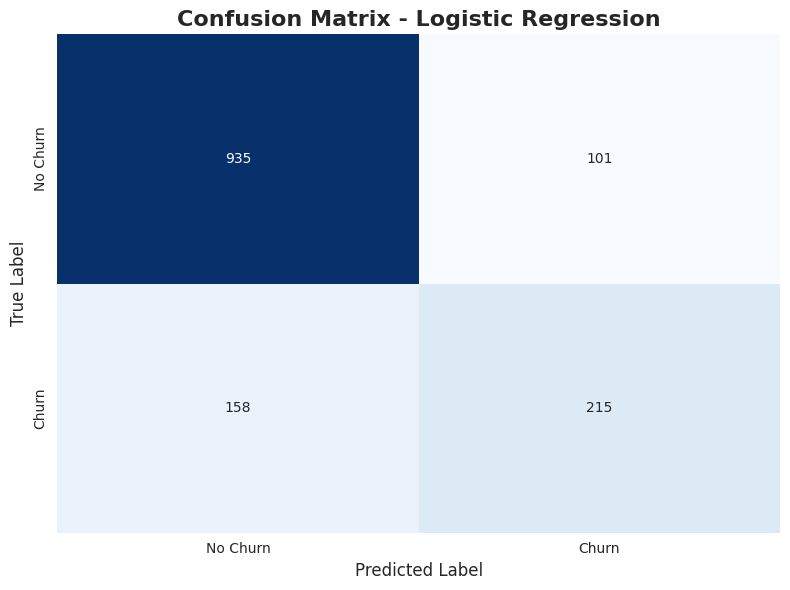

In [26]:
# Better model confusion matrix
if accuracy_score(y_test, y_pred_rf) > accuracy_score(y_test, y_pred_log_reg):
    better_model = "Random Forest"
    better_predictions = y_pred_rf
else:
    better_model = "Logistic Regression"
    better_predictions = y_pred_log_reg

cm = confusion_matrix(y_test, better_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {better_model}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

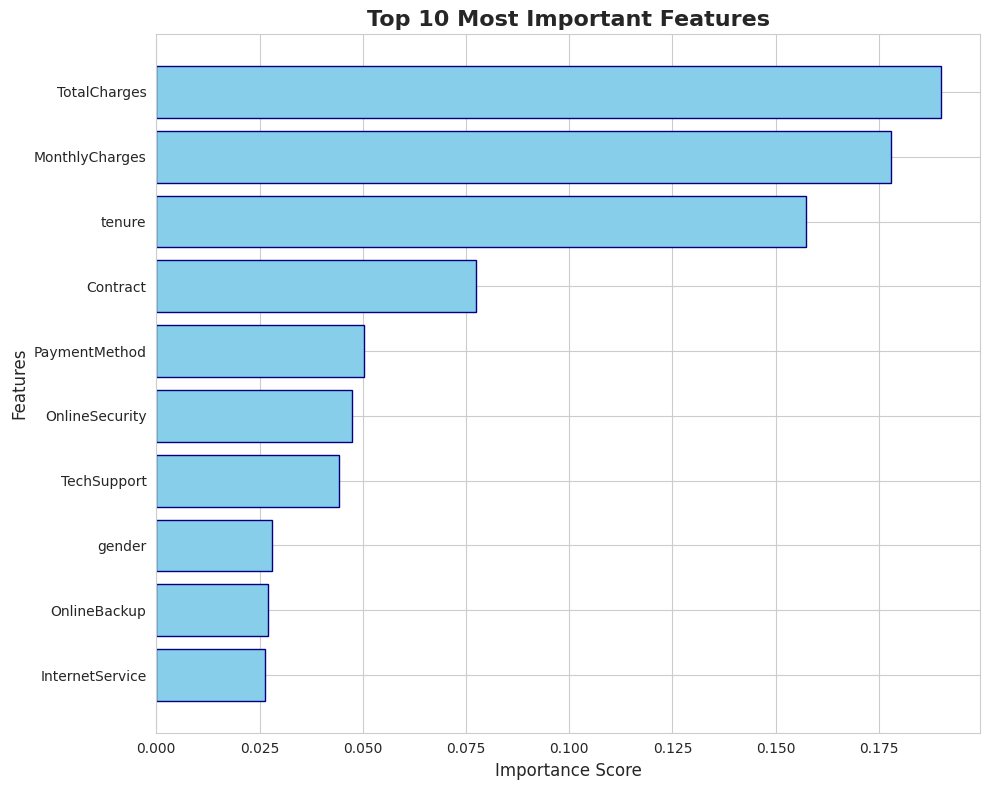


Top 10 Most Important Features:
----------------------------------------
TotalCharges         0.1900
MonthlyCharges       0.1779
tenure               0.1574
Contract             0.0774
PaymentMethod        0.0504
OnlineSecurity       0.0474
TechSupport          0.0442
gender               0.0281
OnlineBackup         0.0271
InternetService      0.0264


In [27]:
# Feature importance from Random Forest
feature_importance = rf_clf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

top_10_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 8))
plt.barh(top_10_features['Feature'], top_10_features['Importance'],
         color='skyblue', edgecolor='navy')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 10 Most Important Features', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print("-" * 40)
for idx, row in top_10_features.iterrows():
    print(f"{row['Feature']:<20} {row['Importance']:.4f}")

In [28]:
# Verification cell
print("="*50)
print("EXECUTION VERIFICATION")
print("="*50)

# Check if data exists
try:
    print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
except:
    print("❌ Data not loaded")

# Check if models exist
try:
    print(f"✅ Logistic Regression trained")
    print(f"✅ Random Forest trained")
except:
    print("❌ Models not trained")

# Check if predictions exist
try:
    print(f"✅ Predictions made")
    print(f"✅ Accuracy calculated")
except:
    print("❌ Predictions missing")

print("="*50)

EXECUTION VERIFICATION
✅ Data loaded: 7043 rows, 20 columns
✅ Logistic Regression trained
✅ Random Forest trained
✅ Predictions made
✅ Accuracy calculated
